# NIFH DIAZATROPS DATA SET FORMATTING
This notebook aims to explore and analyze the data from the 2 datasets with focus on the nifh gene data sheet in .xls file.

In [38]:
import sys
print(sys.executable)

/home/tim/OneDrive/fedora/Documents/SEMESTER4/int/werkstudent/N2-fixers-in-the-ocean/.venv/bin/python


In [39]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

There are some files that need to be present for this notebook to work:
- ***./csv/DiazotrophsDatabase-20240109_nifh.csv***
- ***./csv/MAREDAT_diazotroph_nifh.csv***
- ***./csv/Tang_GeophysicalResLett_2019_Data_nifh.csv***
- ***./csv/Shiozaki_NatGeosc_2020_Data_nifh.csv***

Each takes the data from the nifh_gene sheet of the corresponding exel file that I export as a csv file in order to be processed using pandas.

There are some simple functions we would like to use for both datasets that I also used in another notebook. And since they are useful and can and should be used here I put them into a separate file from where they are imported.

In [40]:
from format import removeEmptyRows, removeRed, objToNum, filterDepth, roundCoord, setND

Since we want to plot the csv data as a scatter plot on the globe quite frequently I thought it would be useful to separate that functionality into a new functiion and generally such functions go into a file. 

In [41]:
from visualize import plotColsOnMap

There is a list of columns we actually want to keep in the final set in order to predict them. Other columns are not needed for this project and can be removed.

In [42]:
keepers = ['LATITUDE', 'LONGITUDE', 'DEPTH (m)','Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)"]

# First dataset
This dataset is from the paper [Global oceanic diazotroph database version 2 and
elevated estimate of global oceanic N2 fixation](https://essd.copernicus.org/articles/15/3673/2023/essd-15-3673-2023-assets.html). (Luo)

In [43]:
#we want to remember which columns here to show
dzdb_cols = ['Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

#the dataset is opened
dzdb_2024_nifh = pd.read_csv(
    "../csv/DiazotrophsDatabase-20240109_nifh.csv",
    keep_default_na=False, 
    na_values=[""]
)
print(dzdb_2024_nifh.info())
dzdb_2024_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5580 entries, 0 to 5579
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   SOURCE: Related article or authors                         143 non-null    object 
 1   METHODS:                  Sampling/Analysis                5580 non-null   object 
 2   DATE (yyyy-mm-dd)                                          5580 non-null   object 
 3   LATITUDE                                                   5580 non-null   float64
 4   LONGITUDE                                                  5580 non-null   float64
 5   DEPTH (m)                                                  5580 non-null   float64
 6   Trichodesmium nifH Gene (x106 copies m-3)                  4515 non-null   object 
 7   UCYN-A1 nifH Gene (x106 copies m-3)                        4721 non-null   object 
 8   UCYN-A2/

,SOURCE: Related article or authors,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A1 nifH Gene (x106 copies m-3),UCYN-A2/A3/A4 nifH Gene (x106 copies m-3),Total UCYN-A nifH Gene (x106 copies m-3),...,Richelia (het-2 or ReuHH01) nifH Gene (x106 copies m-3),Richelia ( RrhiSC01) nifH Gene (x106 copies m-3),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),SiO2 (µM),Chlorophyll (mg m-3),Notes
0,"Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,10/31/2004,-9.00,-136.86,5.0,0.000,0.03,NaN,0.03,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,qPCR,11/3/2004,-11.51,-134.35,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,qPCR,11/4/2004,-13.31,-132.39,70.0,0.000,0.00,NaN,0.00,...,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,qPCR,11/5/2004,-15.20,-130.20,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,qPCR,11/6/2004,-16.87,-128.38,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
setND(dzdb_2024_nifh, dzdb_cols)

#I removed all redundant columns and made everything into a number
removeRed(keepers, dzdb_2024_nifh)
objToNum(dzdb_2024_nifh)

dzdb_2024_nifh_df = dzdb_2024_nifh
# a lot of empty rows are actually no data that corresponds to 0, so they should not be dropped
# However i am concerned that I am imputing not only n.d but also NaN this might need adressing
dzdb_2024_nifh_df = removeEmptyRows(dzdb_cols,dzdb_2024_nifh_df)

#coordinates are rounded
dzdb_2024_nifh_rnd = roundCoord(cols=dzdb_cols+["DEPTH (m)"], df=dzdb_2024_nifh_df)

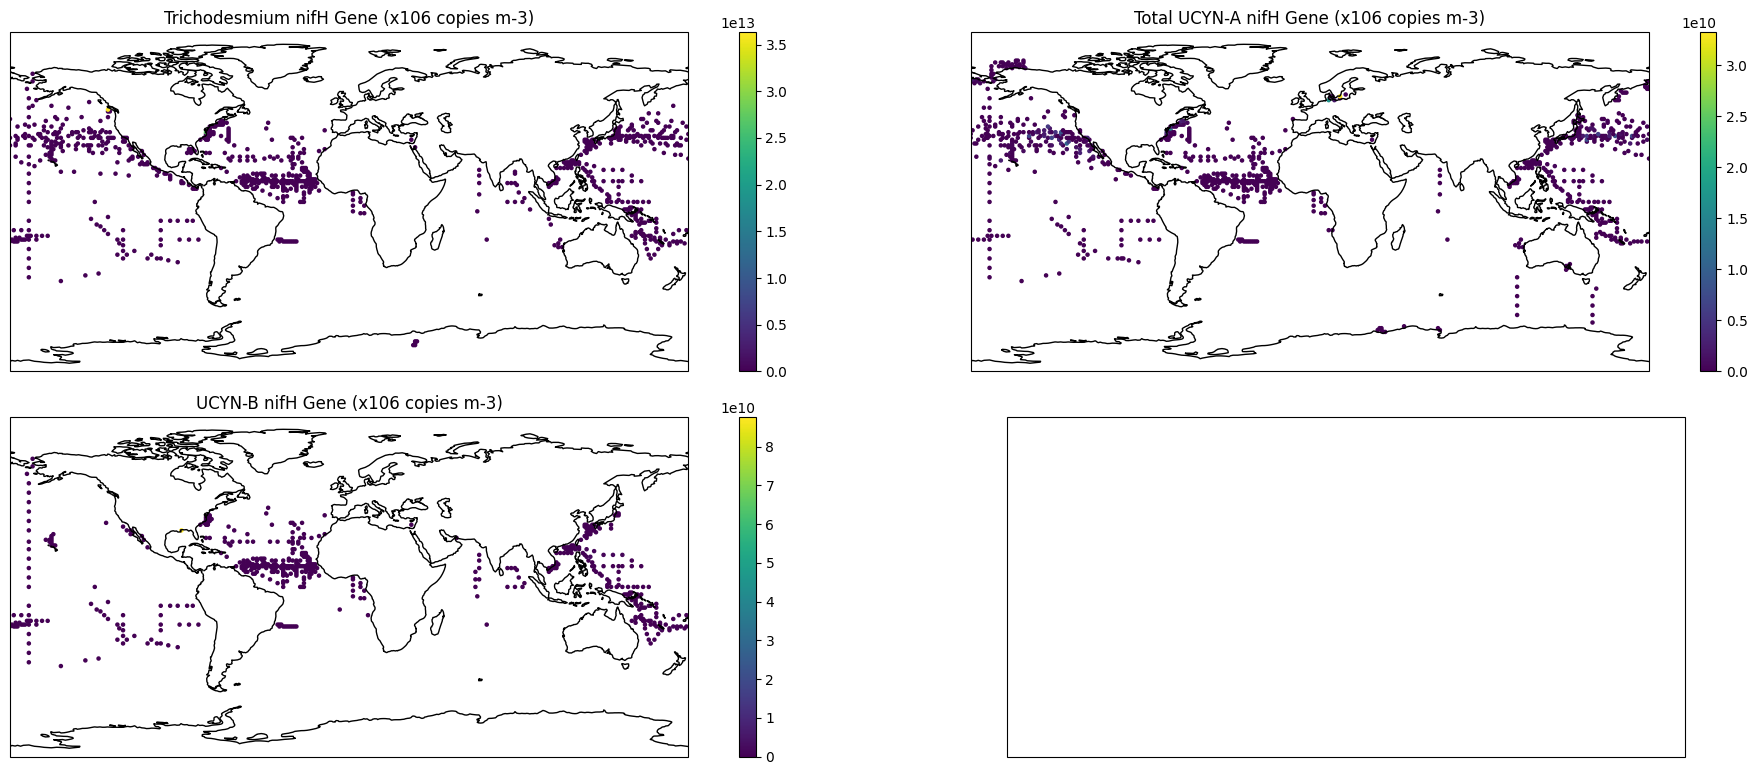

In [45]:
#we also want to plot the contents of the dataset on the map, which we can do now as all data is numeric
plotColsOnMap(dzdb_cols, dzdb_2024_nifh_rnd)

As a result we got a significantly smaller number of entries, which is especially seen with the data columns. But now we only have the data we actually want and need.

In [46]:
dzdb_2024_nifh_rnd.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),Total UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m)
count,4886.000000,4886.000000,3.640000e+03,4149.000000,3485.000000,4886.000000
mean,15.115637,-26.506345,6.255146e+04,226.436633,578.073182,50.315411
std,24.713588,128.621464,3.206037e+06,2101.029336,16664.866743,70.160309
min,-76.000000,-180.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,5.000000,-158.000000,8.575000e-02,0.000000,0.000000,5.000000
50%,21.000000,-54.000000,2.266000e+00,1.100000,0.426000,25.000000
75%,28.000000,117.000000,3.708825e+01,37.289800,6.178000,80.000000
max,120.000000,187.000000,1.900000e+08,99700.000000,898000.000000,1700.000000


# Second dataset
This is the dataset from the  [Database of diazotrophs in global ocean: abundance, biomass and nitrogen fixation rates](https://doi.pangaea.de/10.1594/PANGAEA.774851)

In [47]:
maredat_cols =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)"]

#here we open the dataset of the other database for cell count
maredat_nifh = pd.read_csv(
    "../csv/MAREDAT_diazotroph_nifh.csv",
    keep_default_na=False, 
    na_values=[""]
)

print(maredat_nifh.info())
maredat_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 35 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    825 non-null    object 
 1   SOURCE: Related article                                         878 non-null    object 
 2   METHODS:                  Sampling/Analysis                     921 non-null    object 
 3   DATE (yyyy-mm-dd)                                               921 non-null    object 
 4   LATITUDE                                                        921 non-null    float64
 5   LONGITUDE                                                       921 non-null    float64
 6   DEPTH (m)                                                       921 non-null    int64  
 7   Trichodesmium nifH Gene (x106 copies m-3)            

,SOURCE: Data,SOURCE: Related article,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),...,Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),Chlorophyll (mg m-3),Notes,Gamma A nifH Gene (x106 copies/m3),Gamma P nifH Gene (x106 copies/m3),CIII nifH Gene (x106 copies/m3)
0,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-10-31,-9.00,-136.86,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-03,-11.51,-134.35,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-04,-13.31,-132.39,70,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-05,-15.20,-130.20,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-06,-16.87,-128.38,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
#no data is converted into a 0 
setND(maredat_nifh, maredat_cols)
#I removed all redundant columns and made everything into a number
removeRed(keepers, maredat_nifh)
objToNum(maredat_nifh)

#filtered for depth and removed redundant rows
#maredat_nifh_df = filterDepth(maredat_nifh) no longer filtered
maredat_nifh_df = maredat_nifh
maredat_nifh_df = removeEmptyRows(maredat_cols,maredat_nifh_df)


#coordinates are rounded
maredat_nifh_rnd = roundCoord(maredat_cols+["DEPTH (m)"], maredat_nifh_df)

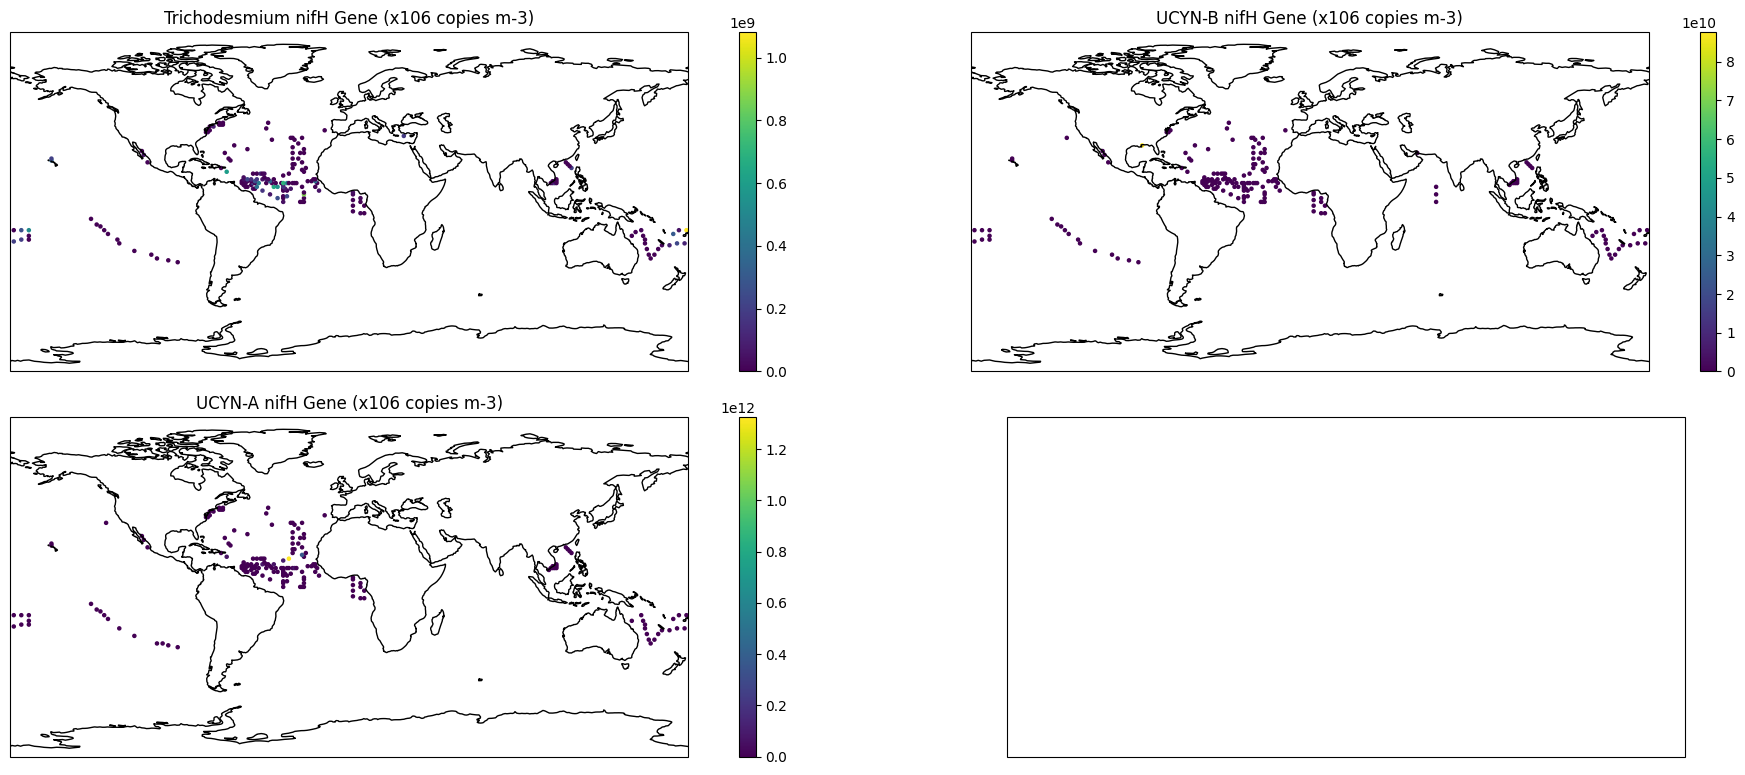

In [49]:
#the points in the dataset are plotted on the map
plotColsOnMap(maredat_cols,maredat_nifh_rnd)

In [50]:
maredat_nifh_rnd.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),DEPTH (m)
count,851.000000,851.000000,759.000000,795.000000,7.710000e+02,851.000000
mean,7.177438,-7.861340,86.870968,2015.057620,2.298771e+04,61.032902
std,17.875524,103.604211,339.894468,34127.777036,2.620895e+05,114.467335
min,-32.000000,-178.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,0.000000,-56.000000,0.010000,0.000000,0.000000e+00,5.000000
50%,10.000000,-35.000000,0.868300,0.010000,1.000000e-02,30.000000
75%,19.000000,108.000000,16.620600,1.979950,1.142735e+01,80.000000
max,42.000000,179.000000,6266.844800,898000.000000,4.810000e+06,1700.000000


# Third dataset

This is an additional dataset that is meant to contain more diverse data than the first 2. It is based on Tang [Data-Driven Modeling of the Distribution of Diazotrophs in the Global Ocean](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2019GL084376)

In [51]:
tang_nifh = pd.read_csv(
    "../csv/Tang_GeophysicalResLett_2019_Data_nifh.csv", 
    keep_default_na=False, 
    na_values=[""]
)

print(tang_nifh.info())
tang_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 43 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    37 non-null     object 
 1   METHODS:                  Sampling/Analysis                     2006 non-null   object 
 2   DATE (mm/dd/yyyy)                                               2006 non-null   object 
 3   LATITUDE                                                        2006 non-null   float64
 4   LONGITUDE                                                       2006 non-null   float64
 5   DEPTH (m)                                                       2006 non-null   object 
 6   Trichodesmium nifH Gene (x106 copies m-3)                       1540 non-null   object 
 7   Trichodesmium Biomass Conversion factor (mg C/106 n

,SOURCE: Data,METHODS: Sampling/Analysis,DATE (mm/dd/yyyy),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),UCYN-A1 nifH Gene (x106 copies m-3),...,Total nifH Gene (x106 copies/m3),Total Diazotrophic Biomass (mg C m-3),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),N:P ratio,Fe (nM),Chlorophyll (mg m-3),Notes
0,"Hannah Halm et al., 2012 ISME",qPCR,Dec 2006/Jan 2007,-27.91,-123.16,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,qPCR,Dec 2006/Jan 2007,-27.91,-123.16,150.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,data shown in Table 2,qPCR,Dec 2006/Jan 2007,-27.73,-117.61,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,qPCR,Dec 2006/Jan 2007,-27.73,-117.61,220.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,qPCR,Dec 2006/Jan 2007,-38.06,-133.10,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
mask = ((tang_nifh["DEPTH (m)"]=="0.00") | (tang_nifh["DEPTH (m)"]=="0")) & (tang_nifh["Trichodesmium nifH Gene (x106 copies m-3)"].notna())
tang_filtered = tang_nifh[mask].copy()

print(len(tang_filtered))

tang_filtered.info()

168
<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 183 to 1588
Data columns (total 43 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    7 non-null      object 
 1   METHODS:                  Sampling/Analysis                     168 non-null    object 
 2   DATE (mm/dd/yyyy)                                               168 non-null    object 
 3   LATITUDE                                                        168 non-null    float64
 4   LONGITUDE                                                       168 non-null    float64
 5   DEPTH (m)                                                       168 non-null    object 
 6   Trichodesmium nifH Gene (x106 copies m-3)                       168 non-null    object 
 7   Trichodesmium Biomass Conversion factor (mg C/106 n

In [53]:
tang_filtered.head()

,SOURCE: Data,METHODS: Sampling/Analysis,DATE (mm/dd/yyyy),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),UCYN-A1 nifH Gene (x106 copies m-3),...,Total nifH Gene (x106 copies/m3),Total Diazotrophic Biomass (mg C m-3),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),N:P ratio,Fe (nM),Chlorophyll (mg m-3),Notes
183,"Shiozaki et al., 2014. GBC",qPCR,27 Nov to 16 Dec 2009,16.75,69.00,0.00,0.16,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188,NaN,qPCR,27 Nov to 16 Dec 2009,14.00,69.00,0.00,0.63,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193,NaN,qPCR,27 Nov to 16 Dec 2009,10.00,68.75,0.00,1.58,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198,NaN,qPCR,27 Nov to 16 Dec 2009,4.02,69.00,0.00,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201,NaN,qPCR,27 Nov to 16 Dec 2009,-5.27,67.90,0.00,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
tang_cols = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

setND(tang_nifh, tang_cols)
#first step
removeRed(keepers, tang_nifh)
objToNum(tang_nifh)

#second step
#tang_nifh_df = filterDepth(tang_nifh)
tang_nifh_df = tang_nifh.copy()
tang_nifh_df = removeEmptyRows(tang_cols,tang_nifh_df)


#coordinates are rounded
tang_nifh_rnd = roundCoord(tang_cols+["DEPTH (m)"], tang_nifh_df)

tang_nifh_rnd.to_csv("../csv/tang.csv", index=False)

tang_nifh_rnd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1820 entries, 0 to 2005
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   1820 non-null   int64  
 1   LONGITUDE                                  1820 non-null   int64  
 2   Trichodesmium nifH Gene (x106 copies m-3)  1539 non-null   float64
 3   UCYN-A nifH Gene (x106 copies m-3)         1733 non-null   float64
 4   UCYN-B nifH Gene (x106 copies m-3)         1563 non-null   float64
 5   DEPTH (m)                                  1817 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 99.5 KB


In [55]:
mask = (tang_nifh_rnd["DEPTH (m)"]==0.0) & (tang_nifh_rnd["Trichodesmium nifH Gene (x106 copies m-3)"].notna())
tang_filtered = tang_nifh_rnd[mask].copy()

print(len(tang_filtered))

tang_filtered.info()

168
<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 183 to 1588
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   168 non-null    int64  
 1   LONGITUDE                                  168 non-null    int64  
 2   Trichodesmium nifH Gene (x106 copies m-3)  168 non-null    float64
 3   UCYN-A nifH Gene (x106 copies m-3)         165 non-null    float64
 4   UCYN-B nifH Gene (x106 copies m-3)         165 non-null    float64
 5   DEPTH (m)                                  168 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 9.2 KB


In [56]:
tang_filtered.head()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m)
183,17,69,0.16,0.0,0.00,0.0
188,14,69,0.63,0.0,0.16,0.0
193,10,69,1.58,0.0,0.00,0.0
198,4,69,0.00,0.0,0.00,0.0
201,-5,68,0.00,0.0,0.00,0.0


In [57]:
#ALTERNATIVE PATH MEANT TO MATCH THE GRAPH IN THE PAPER
'''
tang_nifh_alt = tang_nifh.copy()

#coordinates are rounded
tang_nifh_alt_rnd = roundCoord(tang_cols+["DEPTH (m)"], tang_nifh_alt)
tang_nifh_alt_rnd.fillna(0,inplace=True)#to match the plot
tang_nifh_alt_rnd.to_csv("../csv/tang.csv", index=False)
tang_nifh_alt_rnd.info()
'''


'\ntang_nifh_alt = tang_nifh.copy()\n\n#coordinates are rounded\ntang_nifh_alt_rnd = roundCoord(tang_cols+["DEPTH (m)"], tang_nifh_alt)\ntang_nifh_alt_rnd.fillna(0,inplace=True)#to match the plot\ntang_nifh_alt_rnd.to_csv("../csv/tang.csv", index=False)\ntang_nifh_alt_rnd.info()\n'

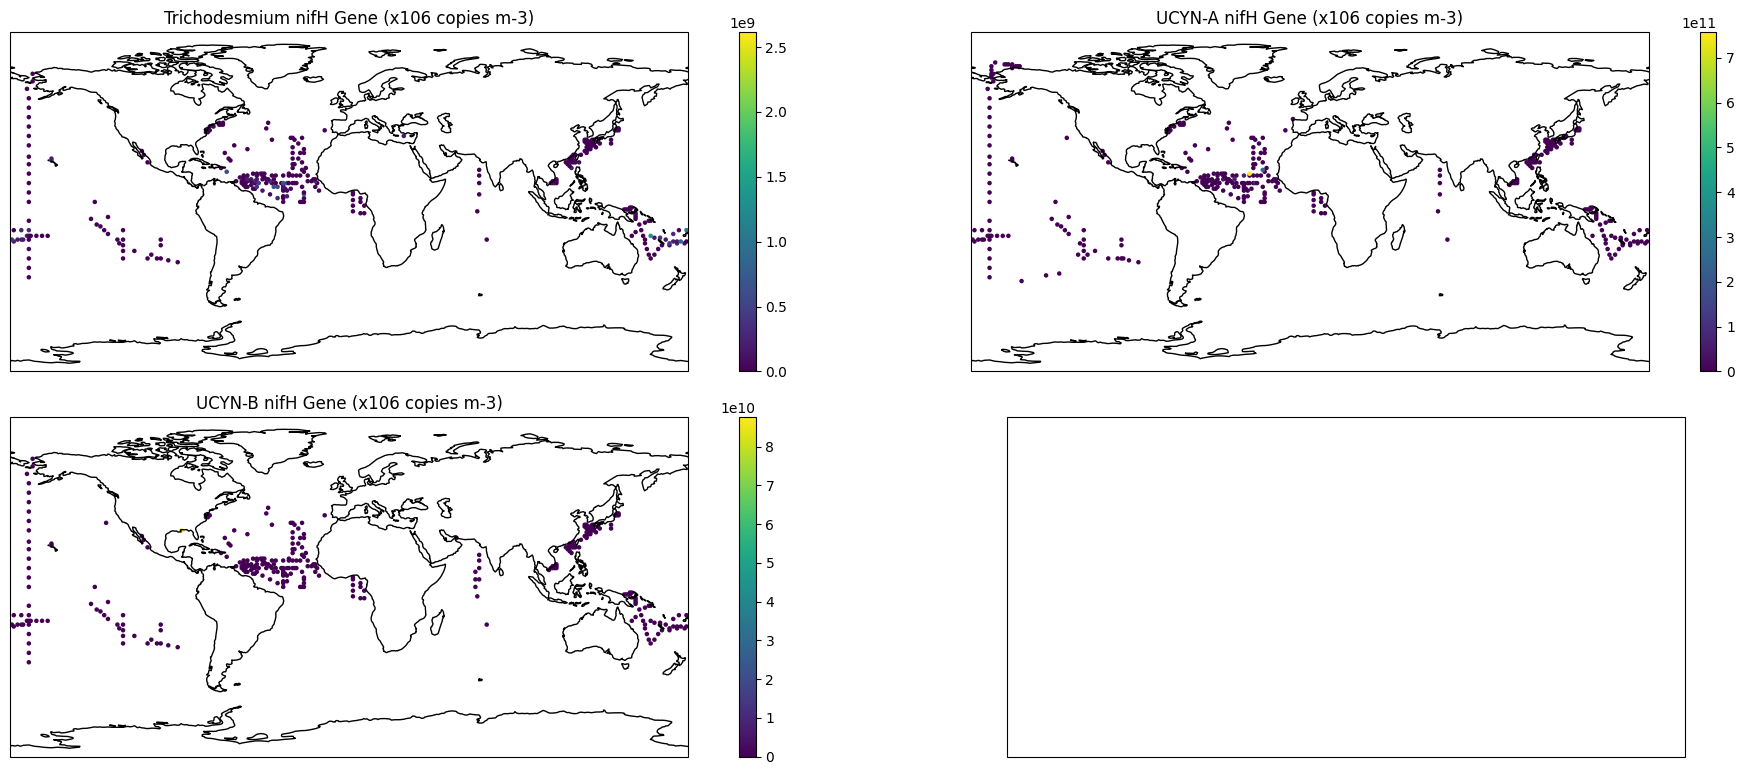

In [58]:

plotColsOnMap(tang_cols,tang_nifh_rnd)

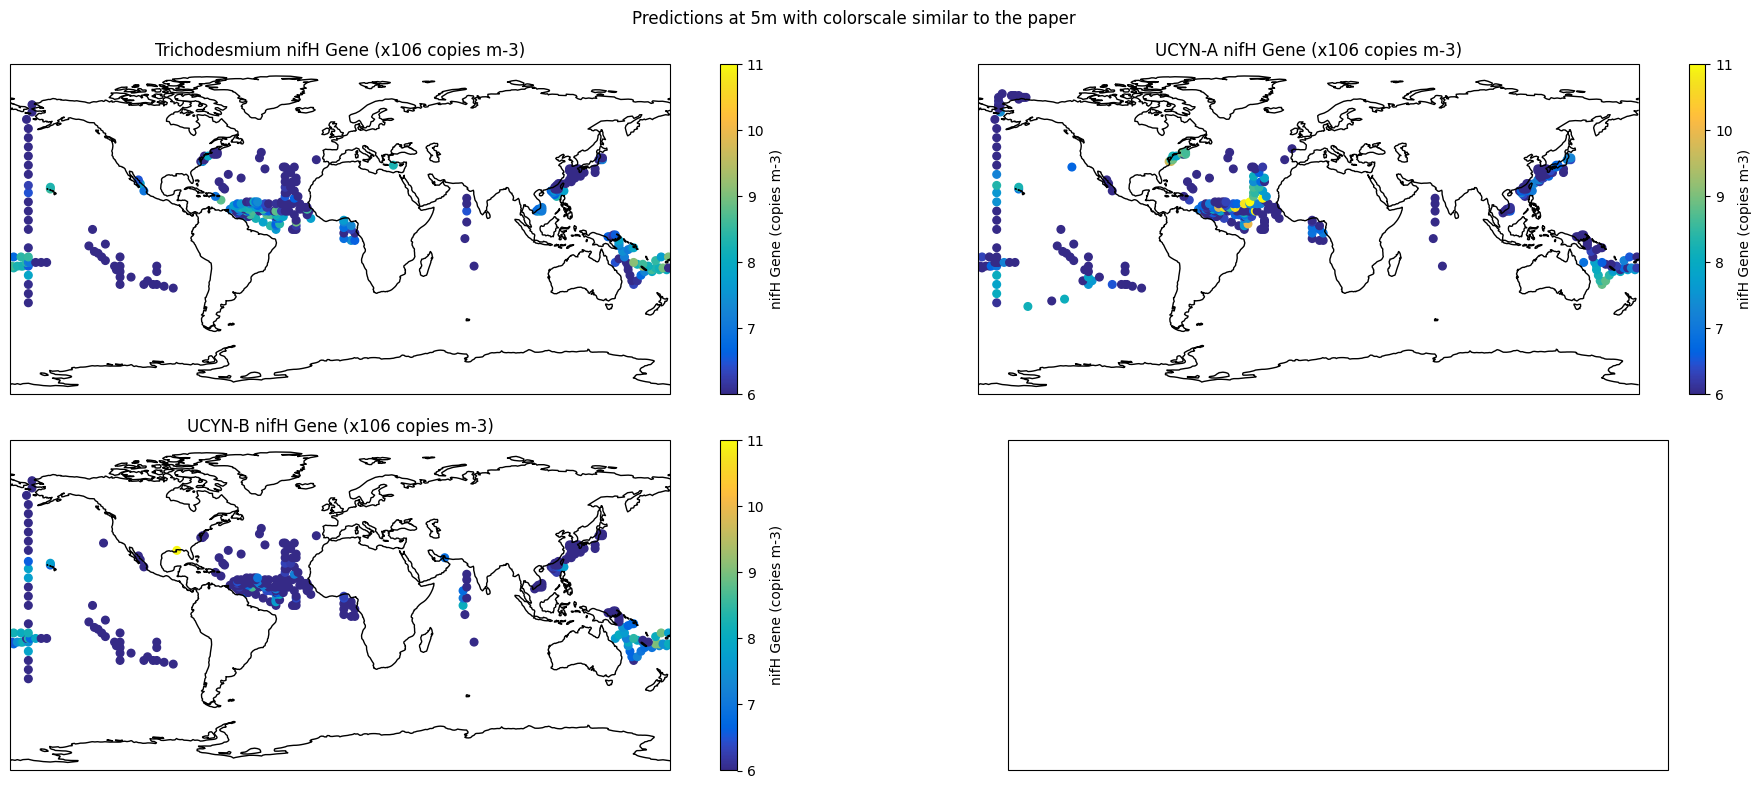

In [59]:
from parula_diy import parula_map

plotColsOnMap(
    tang_cols,tang_nifh_rnd,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Predictions at 5m with colorscale similar to the paper",
    s=30
    )

In [60]:
from parula_diy import parula_map
'''
plotColsOnMap(
    tang_cols,tang_nifh_alt_rnd,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    s=30
    )
    '''

'\nplotColsOnMap(\n    tang_cols,tang_nifh_alt_rnd,\n    constant=(10**6), \n    transf=(lambda x: np.log10(x+10)),\n    min_lim=6,\n    max_lim=11,\n    cmap=parula_map,\n    colorbar_label="nifH Gene (copies m-3)",\n    s=30\n    )\n    '

In [61]:
tang_nifh_rnd.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m)
count,1820.000000,1820.000000,1539.000000,1.733000e+03,1563.000000,1817.000000
mean,10.097253,8.761538,81.739711,7.033437e+03,1040.367088,52.526087
std,24.832654,123.813344,448.370849,1.365295e+05,24352.643959,88.329389
min,-42.000000,-179.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,-15.000000,-100.000000,0.000000,0.000000e+00,0.000000,5.000000
50%,12.000000,-25.000000,0.430000,0.000000e+00,0.010000,27.700000
75%,23.000000,126.000000,10.281000,3.007700e+00,1.723650,75.000000
max,74.000000,179.000000,9413.540000,4.810000e+06,898000.000000,1700.000000


# Fourth dataset for UCYN A

In [62]:
shio_nifh = pd.read_csv(
    "../csv/Shiozaki_NatGeosc_2020_Data_nifh.csv",
    keep_default_na=False, 
    na_values=[""]
)
shio_nifh.drop(0,inplace=True)
print(shio_nifh.info())
shio_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 1 to 22
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         22 non-null     object 
 1   Station                      21 non-null     object 
 2   Longitude                    21 non-null     float64
 3   Latitude                     21 non-null     float64
 4   Surface Nitrate              21 non-null     object 
 5   Surface N/P ratio            21 non-null     float64
 6   Maximum abundance of UCYN-A  21 non-null     object 
dtypes: float64(3), object(4)
memory usage: 1.3+ KB
None


,Date,Station,Longitude,Latitude,Surface Nitrate,Surface N/P ratio,Maximum abundance of UCYN-A
1,12/02/18,L1,110.082048,-40.112552,3.82,10.54,n.d.
2,12/03/18,L2,110.041002,-44.911110,9.82,14.03,n.d.
3,12/04/18,L3,110.004230,-50.101440,22.03,14.84,n.d.
4,12/05/18,L4,110.047067,-55.077642,25.22,14.44,n.d.
5,12/06/18,L5,109.990690,-59.974538,24.87,14.45,84


In [63]:
#we keep only the necessary columns and convert them to numbers
shio_keep = ["Longitude","Latitude", "Maximum abundance of UCYN-A"]
setND(shio_nifh, shio_keep)

removeRed(shio_keep,shio_nifh)
objToNum(shio_nifh)

#empty rows are removed and columns renamed to match the other datasets
shio_keep_data = removeEmptyRows(["Maximum abundance of UCYN-A"],shio_nifh)
rename_shio = {"Longitude":"LONGITUDE","Latitude":"LATITUDE","Maximum abundance of UCYN-A":"UCYN-A nifH Gene (x106 copies m-3)"}
shio_renamed = shio_keep_data.rename(columns=rename_shio)

shio_renamed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 1 to 21
Data columns (total 3 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   LONGITUDE                           21 non-null     float64
 1   LATITUDE                            21 non-null     float64
 2   UCYN-A nifH Gene (x106 copies m-3)  21 non-null     float64
dtypes: float64(3)
memory usage: 672.0 bytes


In [64]:
#the coordinates are rounded, index reset and then the redundant column is removed
shio_rnd = roundCoord(["UCYN-A nifH Gene (x106 copies m-3)"],shio_renamed).reset_index().drop(columns=["index"])
# the data is converted into a cprresponding unit
shio_rnd["UCYN-A nifH Gene (x106 copies m-3)"]=shio_rnd["UCYN-A nifH Gene (x106 copies m-3)"]/1000
shio_rnd.head()

,LATITUDE,LONGITUDE,UCYN-A nifH Gene (x106 copies m-3)
0,-40,110,0.000
1,-45,110,0.000
2,-50,110,0.000
3,-55,110,0.000
4,-60,110,0.084


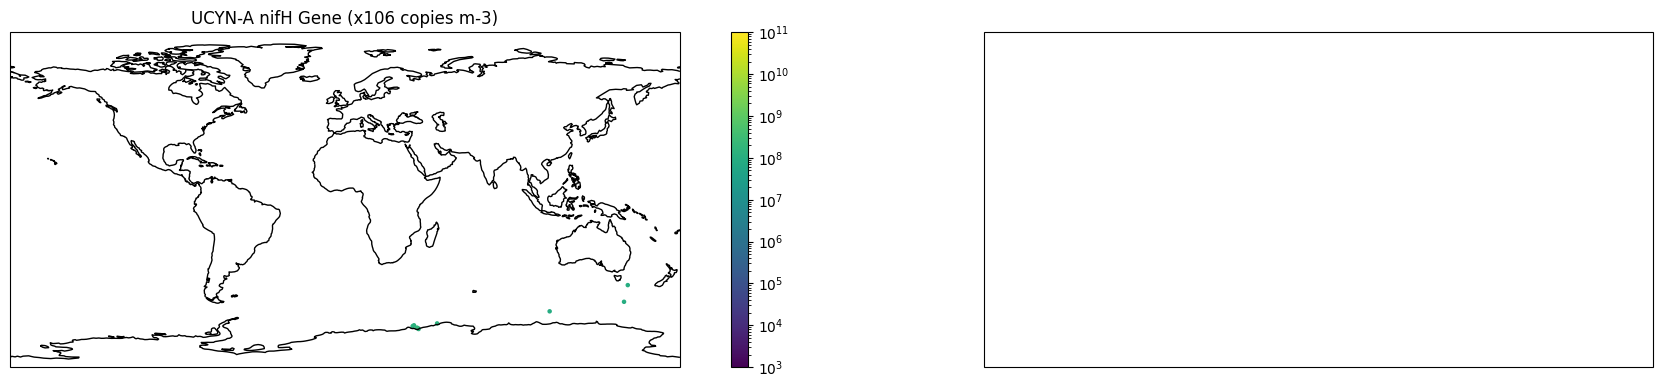

In [65]:
plotColsOnMap(["UCYN-A nifH Gene (x106 copies m-3)"],shio_renamed, log_range=True)

# Combining all of them together into 1
Since both datasets have been cleaned and prepared, we can finally try joining them together into a single table that we can later combine with environmental data and train the model.

The first step is to rename the column names that do not match and concatenate the 2 dataframes together into a single one.

In [66]:
#final data columns that we intend to keep
bact_cols=['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

rename_map = {"Total UCYN-A nifH Gene (x106 copies m-3)":"UCYN-A nifH Gene (x106 copies m-3)"}

#we rename the mismatched column and combine the results
dzdb_2024_nifh_renamed = dzdb_2024_nifh_rnd.rename(columns=rename_map)
combined_df = pd.concat([dzdb_2024_nifh_renamed, maredat_nifh_rnd, tang_nifh_rnd, shio_rnd])

combined_df.head()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),DEPTH (m)
0,-9,-137,0.0,0.03,0.0,5.0
1,-12,-134,0.0,0.00,0.0,5.0
2,-13,-132,0.0,0.00,0.0,70.0
3,-15,-130,0.0,0.00,0.0,5.0
4,-17,-128,0.0,0.00,0.0,5.0


So far there is one of the coordinates which is a float instead of int, this can be fixed.

In [67]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7578 entries, 0 to 20
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   7578 non-null   int64  
 1   LONGITUDE                                  7578 non-null   int64  
 2   Trichodesmium nifH Gene (x106 copies m-3)  5938 non-null   float64
 3   UCYN-A nifH Gene (x106 copies m-3)         6674 non-null   float64
 4   UCYN-B nifH Gene (x106 copies m-3)         5843 non-null   float64
 5   DEPTH (m)                                  7554 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 414.4 KB


In [68]:
#we cannot convert to integer a nan or inf value so i make an assumption that those points belong on the surface
combined_df["DEPTH (m)"]=combined_df["DEPTH (m)"].fillna(0)
combined_df = roundCoord(cols=bact_cols, df=combined_df, coord_cols=["LATITUDE", "LONGITUDE","DEPTH (m)"])

In [69]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7578 entries, 0 to 20
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   7578 non-null   int64  
 1   LONGITUDE                                  7578 non-null   int64  
 2   DEPTH (m)                                  7578 non-null   int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  5938 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         6674 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         5843 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 414.4 KB


In [70]:
#save the data
combined_df.to_csv("../csv/features/bact_data.csv", index=False)

After joining them together we want to plot the distributions in the resulting data.*bact_cols* list all columns that contain bacterial data, that we want to show.

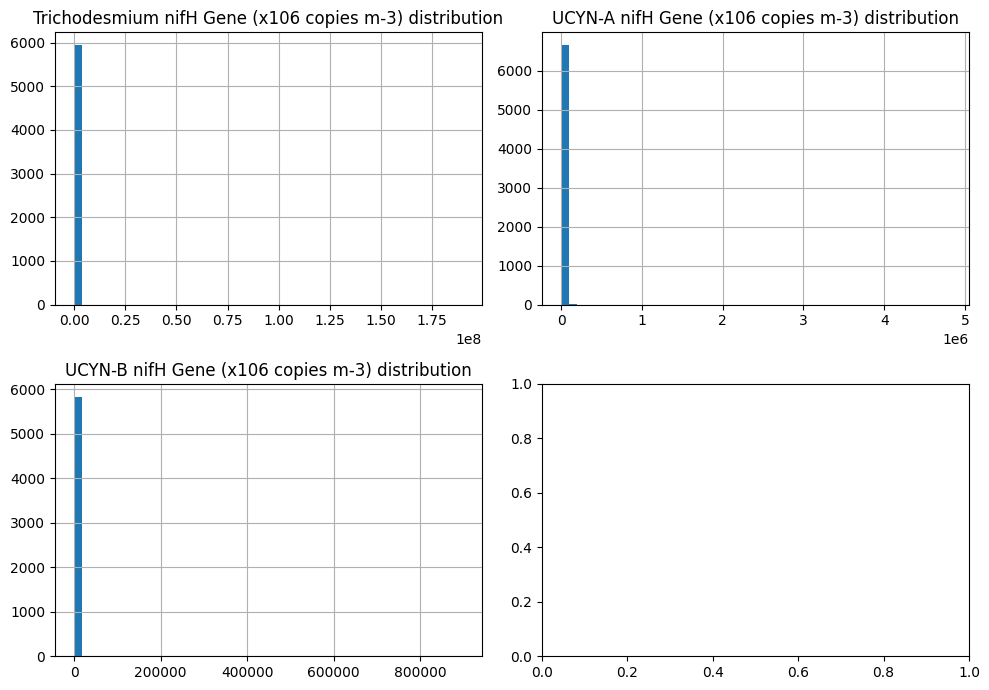

In [71]:
#I want to see the distributions of each variable to see what we are working with 
figure, axis = plt.subplots(2, 2, figsize = (10,7))

#i want to see distributions of the points
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]
    
    combined_df[bact].hist(bins=50,ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

We know from plotting data on a map and the initial plots in the paper, that the authors multiplied it by $10^6$ and plotted on a logarithmic scale. So, I wanted to try multiplication and then taking the logorithm to see the possible results.

0.0
0.0
0.0


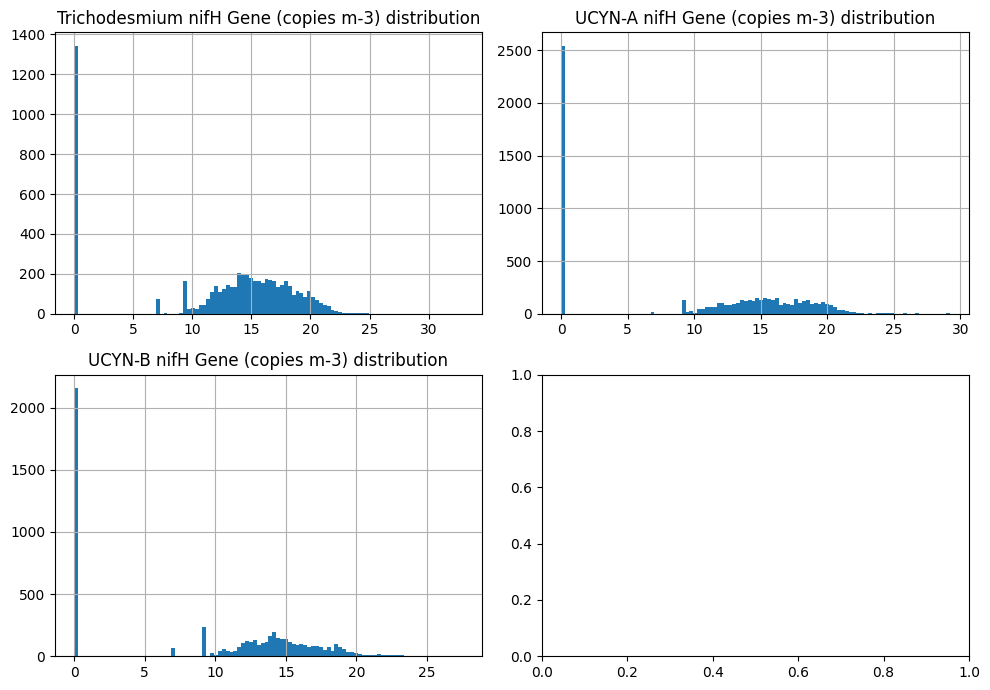

In [72]:
#another plot, but here the data is modified
figure, axis = plt.subplots(2, 2, figsize = (10,7))

#i want to see distributions of the points when we modify it
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]

    mod_ar = np.log(combined_df[bact]*(10**6)+1)
    print(mod_ar.min())
    
    mod_ar.hist(bins=100,ax=ax)
    ax.set_title(title.replace("x106 ",""))

plt.tight_layout()
plt.show()

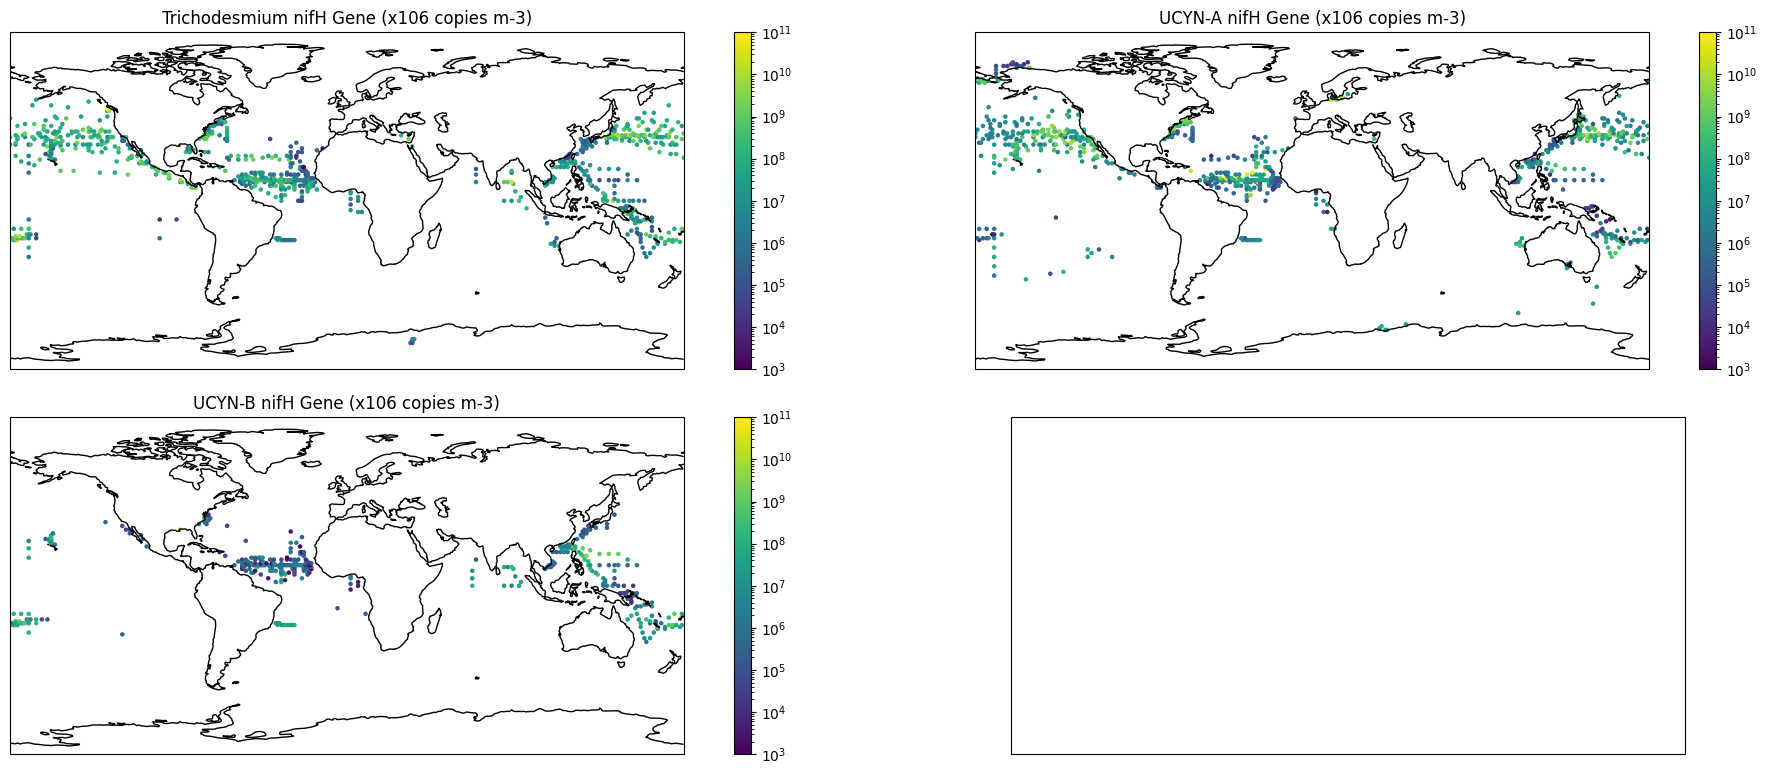

In [73]:
plotColsOnMap(bact_cols, combined_df,True)

In [74]:
combined_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,7578.000000,7578.000000,7578.000000,5.938000e+03,6.674000e+03,5843.000000
mean,12.809184,-15.631829,51.887437,3.837640e+04,4.622709e+03,897.253056
std,24.526951,125.738771,80.828437,2.510198e+06,1.132243e+05,21970.971215
min,-76.000000,-180.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,-158.000000,5.000000,1.000000e-02,0.000000e+00,0.000000
50%,17.000000,-39.000000,25.000000,1.495000e+00,3.085000e-01,0.187100
75%,25.000000,118.000000,75.750000,2.480000e+01,1.585000e+01,3.800000
max,120.000000,187.000000,1700.000000,1.900000e+08,4.810000e+06,898000.000000
